# Customer Segmentation Analysis
### K-Means Clustering for Customer Groups


### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Loading and Preparing Data

In [98]:
# Load the data
df = pd.read_csv("../data/raw/Mall_Customer.csv")
print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(50)

Dataset loaded!
Shape: (15079, 5)

First few rows:


,Customer ID,Age,Gender,Annual Income,Spending Score
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30,Male,151479,89
1,1770b26f-493f-46b6-837f-4237fb5a314e,58,Female,185088,95
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62,Female,70912,76
3,9795712a-ad19-47bf-8886-4f997d6046e3,23,Male,55460,57
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24,Male,153752,76
5,7e211337-e92f-4140-8231-5c9ac7a2aa12,42,Male,158335,40
6,30661d57-eeb5-4886-970a-9c7d0f260ad8,27,Female,163501,37
7,43417ade-6b17-431e-ae76-d8ed26aa46ac,24,Male,70476,17
8,86f73b1a-6a91-4d7e-ad21-0aefcf6111cc,83,Male,47743,34
9,b20fe0a0-e254-4116-b804-5403bb2f59ea,62,Female,63448,3


In [99]:
df.rename(columns={"Genre": "Gender"}, inplace=True)
df['Gender_num'] = (df['Gender'] == 'Female').astype(int)

print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nData Info:")
df.info()

Missing Values:
Customer ID       0
Age               0
Gender            0
Annual Income     0
Spending Score    0
Gender_num        0
dtype: int64

Duplicate rows: 0

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 15079 entries, 0 to 15078
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer ID     15079 non-null  str  
 1   Age             15079 non-null  int64
 2   Gender          15079 non-null  str  
 3   Annual Income   15079 non-null  int64
 4   Spending Score  15079 non-null  int64
 5   Gender_num      15079 non-null  int64
dtypes: int64(4), str(2)
memory usage: 707.0 KB


In [100]:
num_cols = ['Age', 'Annual Income', 'Spending Score']
print("Statistical Summary:")
df[num_cols].describe().round(2)

Statistical Summary:


,Age,Annual Income,Spending Score
count,15079.00,15079.00,15079.00
mean,54.19,109742.88,50.59
std,21.12,52249.43,28.73
min,18.00,20022.00,1.00
25%,36.00,64141.00,26.00
50%,54.00,109190.00,51.00
75%,72.00,155008.00,75.00
max,90.00,199974.00,100.00



## Data Visualization Section

### Histogram: Age Distribution

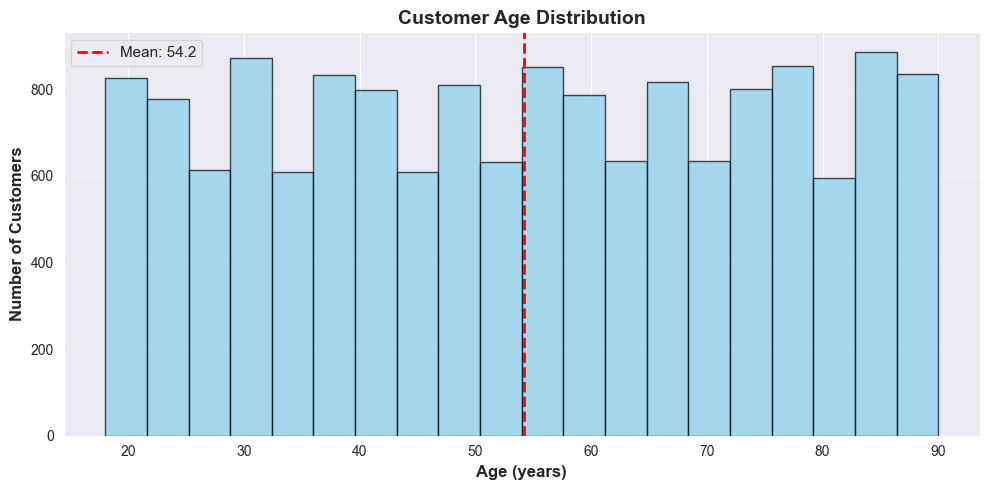

Age Statistics: Mean=54.2, Std=21.1, Min=18, Max=90


In [101]:
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
plt.xlabel('Age (years)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Age Statistics: Mean={df['Age'].mean():.1f}, Std={df['Age'].std():.1f}, Min={df['Age'].min()}, Max={df['Age'].max()}")

### Histogram: Income Distribution

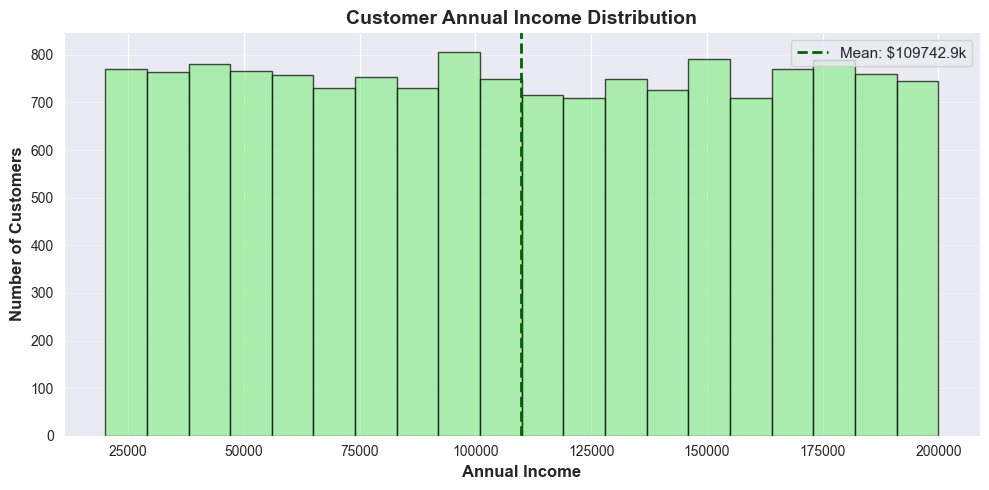

Income Statistics: Mean=$109742.9k, Std=$52249.4k


In [102]:
plt.figure(figsize=(10, 5))
plt.hist(df['Annual Income'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(df['Annual Income'].mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Mean: ${df["Annual Income"].mean():.1f}k')
plt.xlabel('Annual Income', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Annual Income Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Income Statistics: Mean=${df['Annual Income'].mean():.1f}k, Std=${df['Annual Income'].std():.1f}k")

### Histogram: Spending Score Distribution

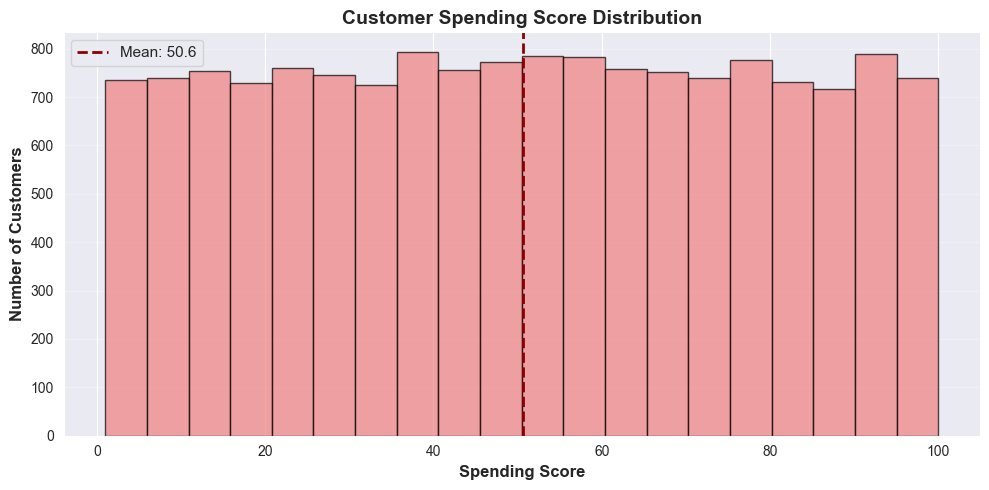

Spending Score Statistics: Mean=50.6, Std=28.7


In [103]:
plt.figure(figsize=(10, 5))
plt.hist(df['Spending Score'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(df['Spending Score'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {df["Spending Score"].mean():.1f}')
plt.xlabel('Spending Score', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Spending Score Distribution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Spending Score Statistics: Mean={df['Spending Score'].mean():.1f}, Std={df['Spending Score'].std():.1f}")

### Donut Chart: Gender Distribution

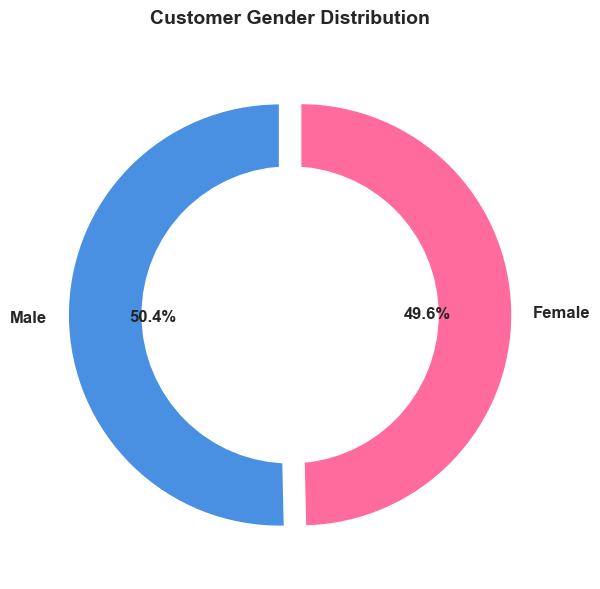

Gender Distribution:
  Male: 7595 customers (50.4%)
  Female: 7484 customers (49.6%)


In [104]:
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
colors = ['#4A90E2', '#FF6B9D']
explode = (0.05, 0.05)

wedges, texts, autotexts = plt.pie(gender_counts, 
                                     labels=gender_counts.index,
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'})

# Draw circle for donut
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Gender Distribution:")
for gender, count in gender_counts.items():
    percentage = (count/len(df))*100
    print(f"  {gender}: {count} customers ({percentage:.1f}%)")

### Bar Chart: Average Age by Gender

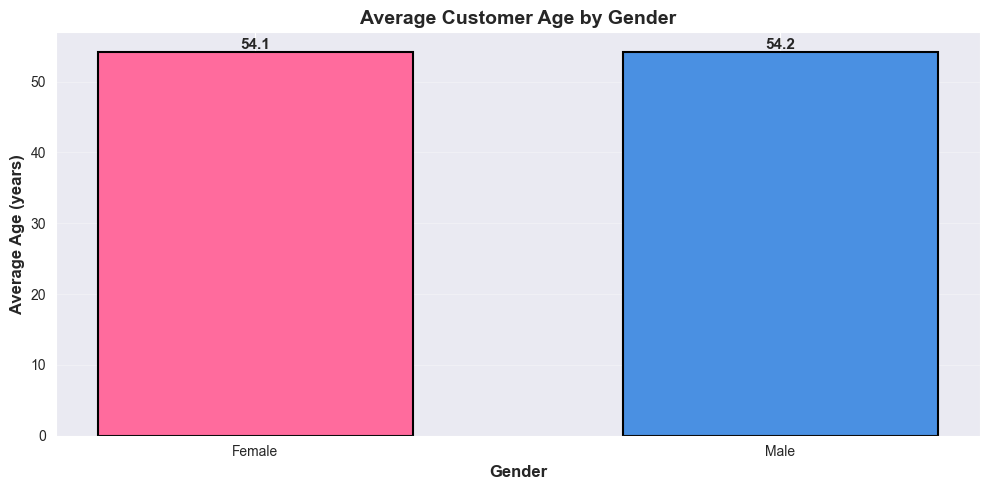

Average Age by Gender:
Gender
Female    54.148316
Male      54.234233
Name: Age, dtype: float64


In [105]:
plt.figure(figsize=(10, 5))
avg_age = df.groupby('Gender')['Age'].mean()
bars = plt.bar(avg_age.index, avg_age.values, color=['#FF6B9D', '#4A90E2'], edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('Average Age (years)', fontsize=12, fontweight='bold')
plt.title('Average Customer Age by Gender', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Age by Gender:")
print(avg_age)

### Bar Chart: Average Income by Gender

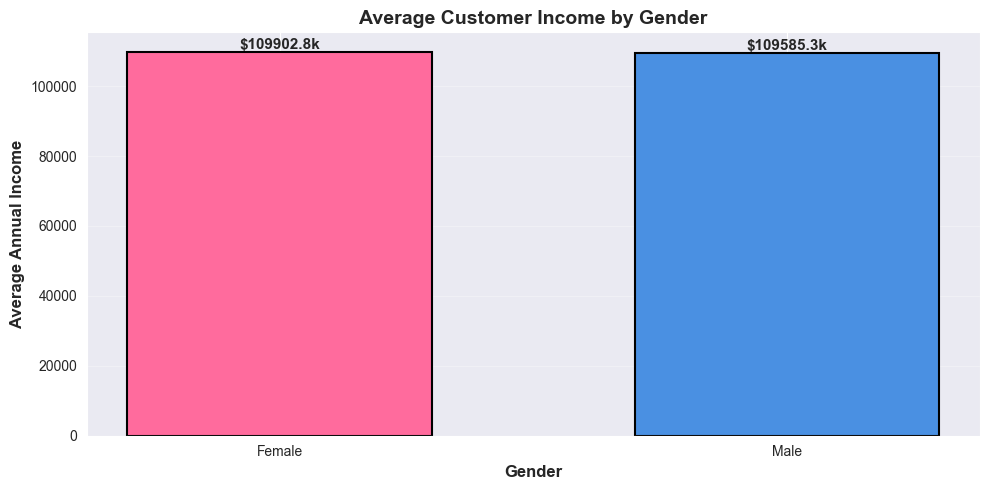

Average Income by Gender:
Gender
Female    109902.799572
Male      109585.298749
Name: Annual Income, dtype: float64


In [106]:
plt.figure(figsize=(10, 5))
avg_income = df.groupby('Gender')['Annual Income'].mean()
bars = plt.bar(avg_income.index, avg_income.values, color=['#FF6B9D', '#4A90E2'], edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.1f}k', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.ylabel('Average Annual Income', fontsize=12, fontweight='bold')
plt.title('Average Customer Income by Gender', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Income by Gender:")
print(avg_income)

### Scatter Plot: Income vs Spending Score

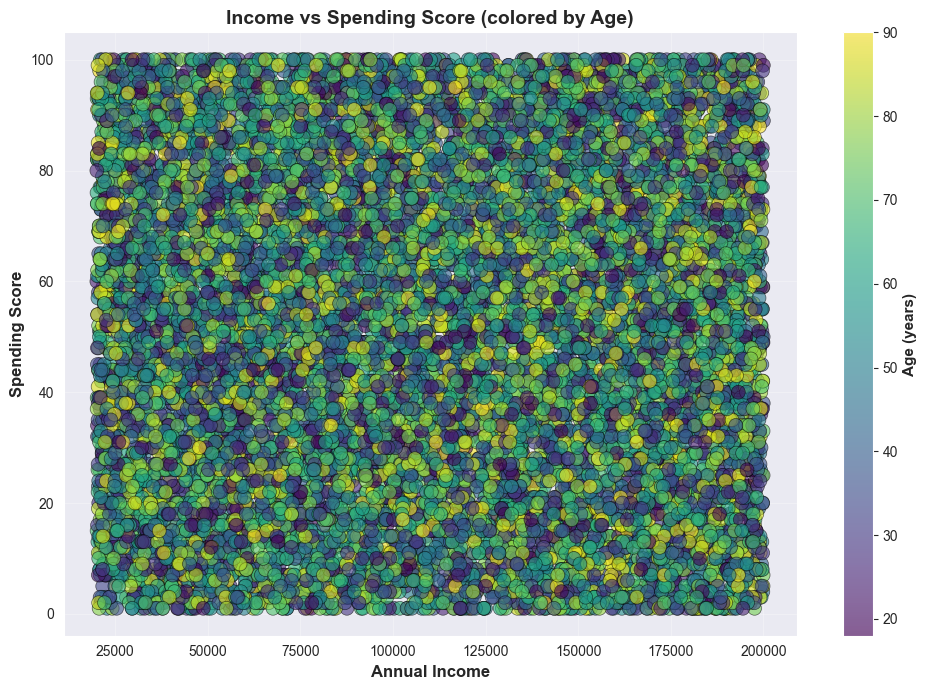

Correlation between Income and Spending Score: 0.003


In [107]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Annual Income'], 
                     df['Spending Score'],
                     c=df['Age'],
                     cmap='viridis',
                     s=100,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

plt.xlabel('Annual Income', fontsize=12, fontweight='bold')
plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
plt.title('Income vs Spending Score (colored by Age)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Age (years)', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['Annual Income'].corr(df['Spending Score'])
print(f"Correlation between Income and Spending Score: {correlation:.3f}")

### Scatter Plot: Age vs Income

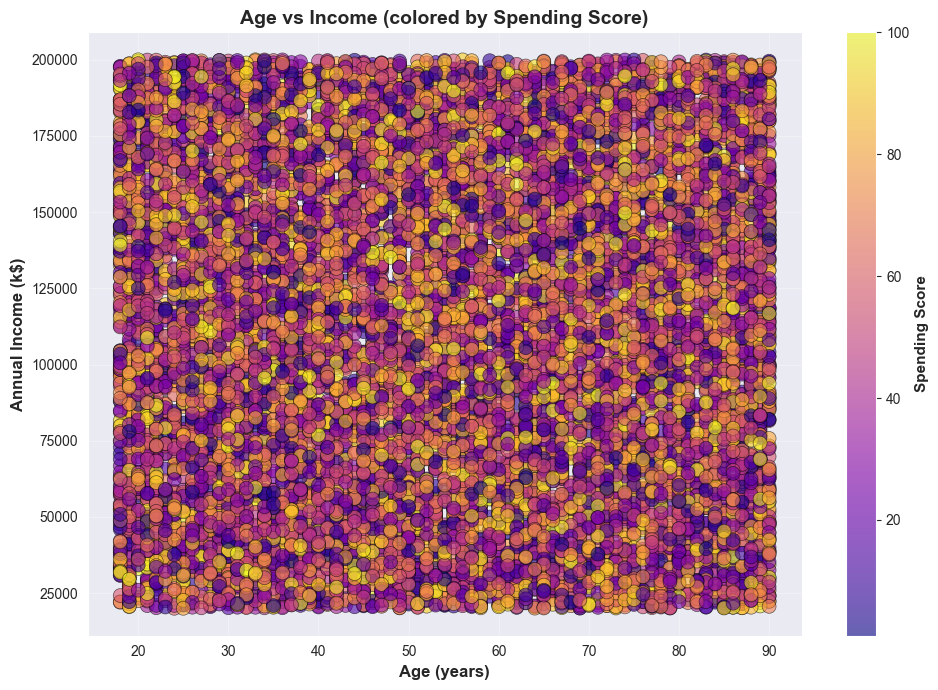

Correlation between Age and Income: 0.005


In [108]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Age'], 
                     df['Annual Income'],
                     c=df['Spending Score'],
                     cmap='plasma',
                     s=100,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

plt.xlabel('Age (years)', fontsize=12, fontweight='bold')
plt.ylabel('Annual Income (k$)', fontsize=12, fontweight='bold')
plt.title('Age vs Income (colored by Spending Score)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Spending Score', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['Age'].corr(df['Annual Income'])
print(f"Correlation between Age and Income: {correlation:.3f}")

### Scatter Plot: Age vs Spending Score

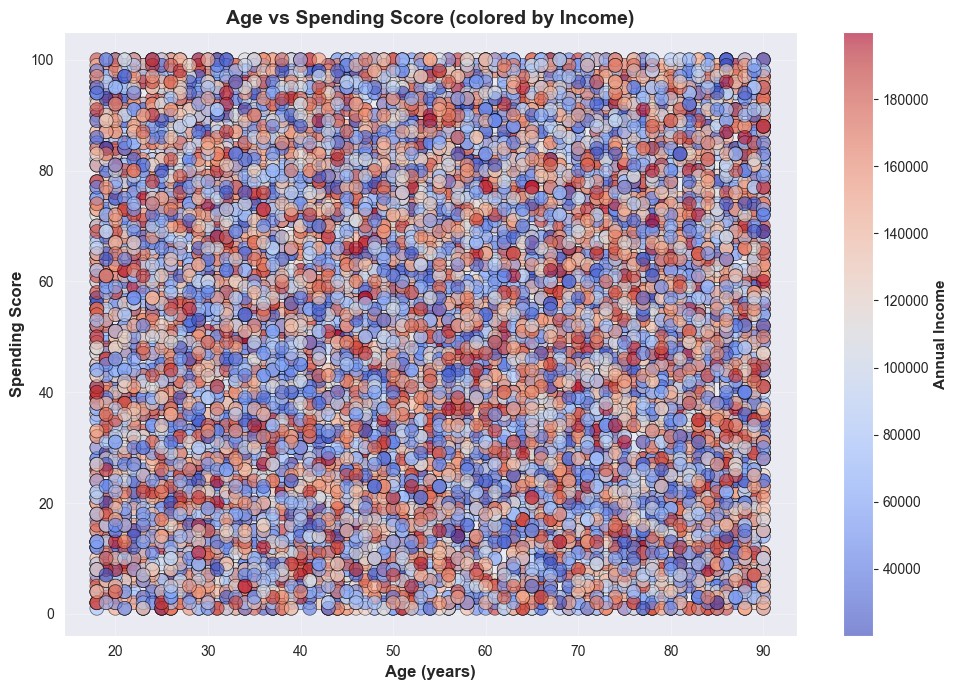

Correlation between Age and Spending Score: -0.008


In [109]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Age'], 
                     df['Spending Score'],
                     c=df['Annual Income'],
                     cmap='coolwarm',
                     s=100,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

plt.xlabel('Age (years)', fontsize=12, fontweight='bold')
plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
plt.title('Age vs Spending Score (colored by Income)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Annual Income', fontsize=11, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['Age'].corr(df['Spending Score'])
print(f"Correlation between Age and Spending Score: {correlation:.3f}")


## K-Means Clustering Analysis

### Prepare Data for Clustering

In [110]:
# Select features for clustering
X = df[['Annual Income', 'Spending Score']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data prepared for clustering!")
print(f"Shape: {X_scaled.shape}")

Data prepared for clustering!
Shape: (15079, 2)


### Find Optimal Number of Clusters (Elbow Method)

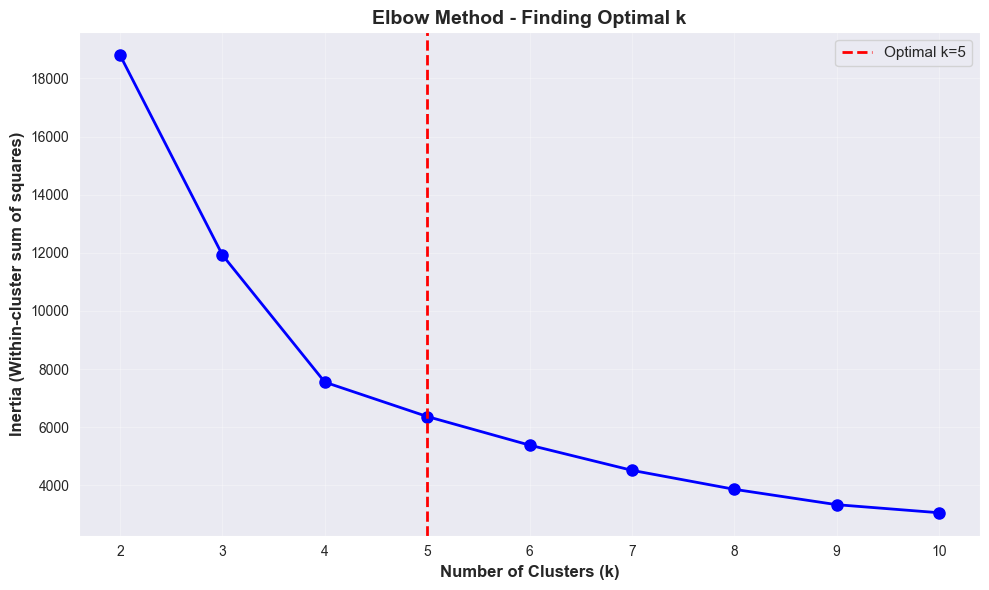

Inertia values: ['18798.27', '11921.61', '7548.69', '6366.34', '5382.11', '4515.27', '3861.70', '3332.91', '3055.74']


In [111]:
# Calculate inertia for different k values
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12, fontweight='bold')
plt.title('Elbow Method - Finding Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal k=5')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Inertia values: {[f'{i:.2f}' for i in inertias]}")

### Apply K-Means with Optimal k=5

In [112]:
# Apply K-Means with k=5
BEST_K = 5
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Get cluster centers in original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(f"K-Means Clustering Complete with k={BEST_K}")
print(f"\nCluster Centers (in original scale):")
centers_df = pd.DataFrame(centers, columns=['Annual Income', 'Spending Score'])
centers_df.index.name = 'Cluster'
print(centers_df.round(2))

K-Means Clustering Complete with k=5

Cluster Centers (in original scale):
         Annual Income  Spending Score
Cluster                               
0            160267.34           77.74
1            106042.93           51.50
2            160477.35           23.28
3             59520.11           22.52
4             58873.09           78.95


### Scatter Plot: Customer Segments (Clusters)

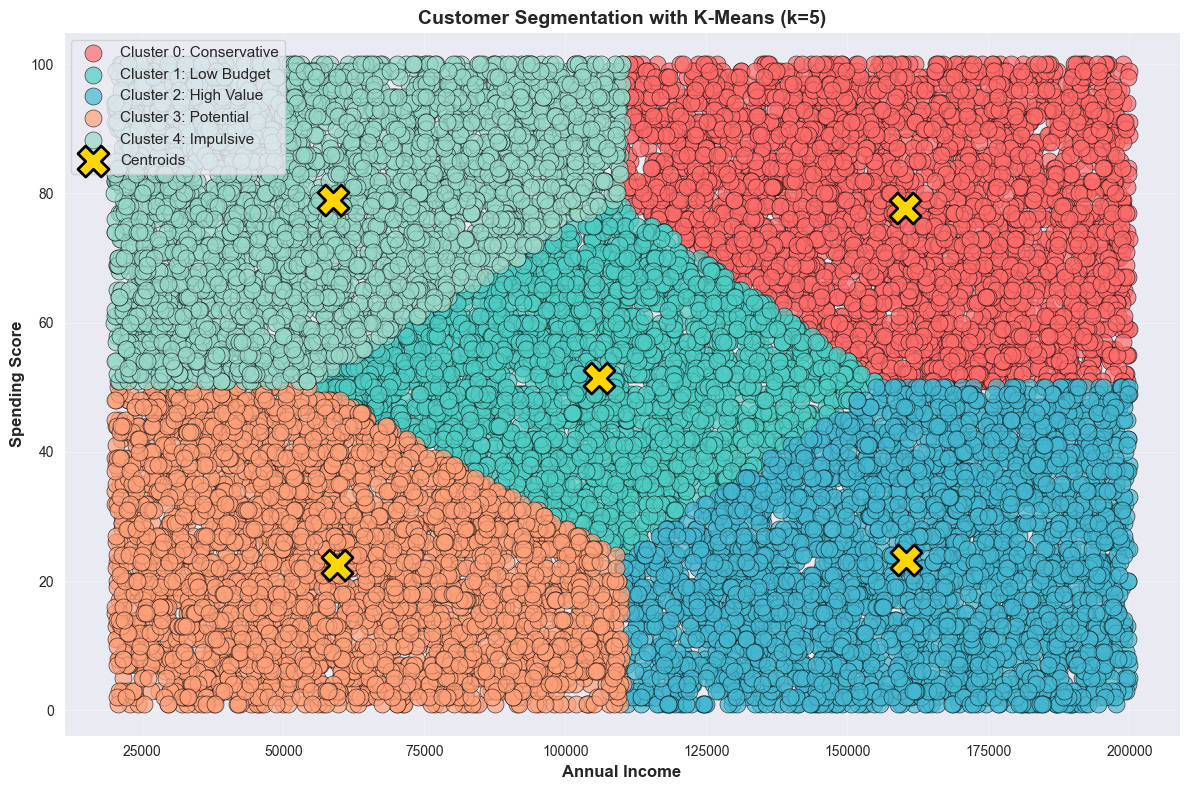


Cluster Distribution:
Cluster
0    3231
1    2355
2    3195
3    3209
4    3089
Name: count, dtype: int64


In [113]:
plt.figure(figsize=(12, 8))

# Define colors for each cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
labels_map = {0: 'Conservative', 1: 'Low Budget', 2: 'High Value', 3: 'Potential', 4: 'Impulsive'}

# Plot each cluster
for cluster in range(BEST_K):
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['Annual Income'], 
               cluster_data['Spending Score'],
               c=colors[cluster],
               label=f'Cluster {cluster}: {labels_map[cluster]}',
               s=150,
               alpha=0.7,
               edgecolors='black',
               linewidth=0.5)

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1],
           c='gold',
           marker='X',
           s=500,
           edgecolors='black',
           linewidth=2,
           label='Centroids',
           zorder=5)

plt.xlabel('Annual Income', fontsize=12, fontweight='bold')
plt.ylabel('Spending Score', fontsize=12, fontweight='bold')
plt.title(f'Customer Segmentation with K-Means (k={BEST_K})', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nCluster Distribution:")
print(df['Cluster'].value_counts().sort_index())

### Bar Chart: Cluster Sizes

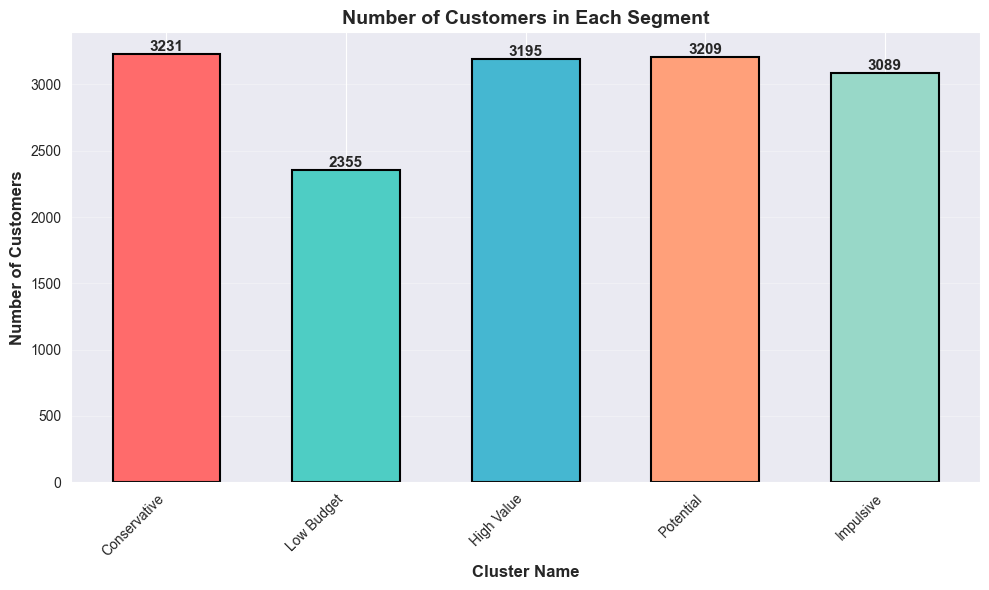

In [114]:
plt.figure(figsize=(10, 6))
cluster_sizes = df['Cluster'].value_counts().sort_index()
bars = plt.bar([labels_map[c] for c in cluster_sizes.index], cluster_sizes.values, 
               color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Cluster Name', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Number of Customers in Each Segment', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Cluster Profiling & Characteristics

### Bar Chart: Average Age by Cluster

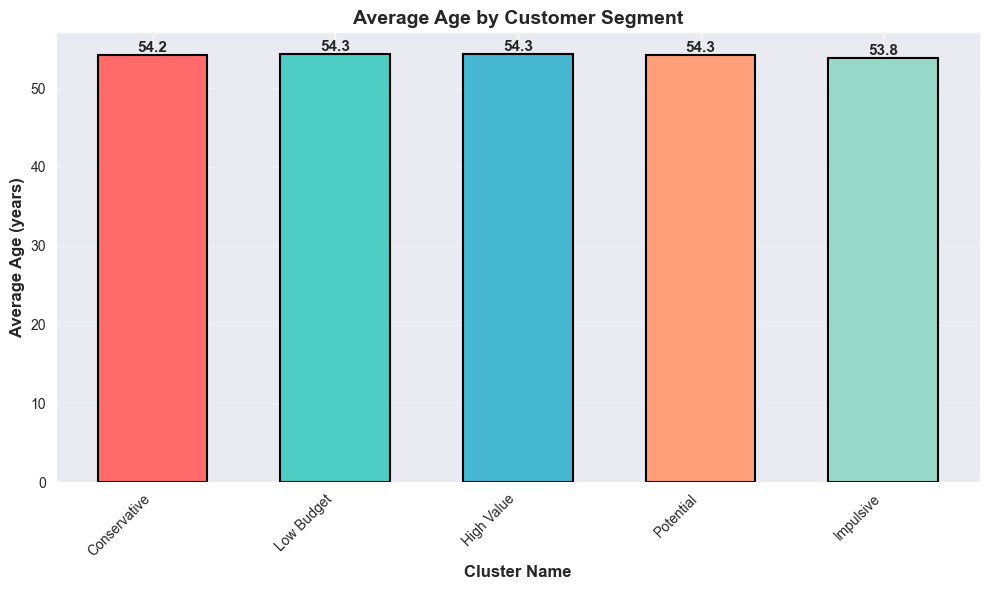

In [115]:
plt.figure(figsize=(10, 6))
avg_age_cluster = df.groupby('Cluster')['Age'].mean()
bars = plt.bar([labels_map[c] for c in avg_age_cluster.index], avg_age_cluster.values,
               color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Cluster Name', fontsize=12, fontweight='bold')
plt.ylabel('Average Age (years)', fontsize=12, fontweight='bold')
plt.title('Average Age by Customer Segment', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bar Chart: Average Income by Cluster

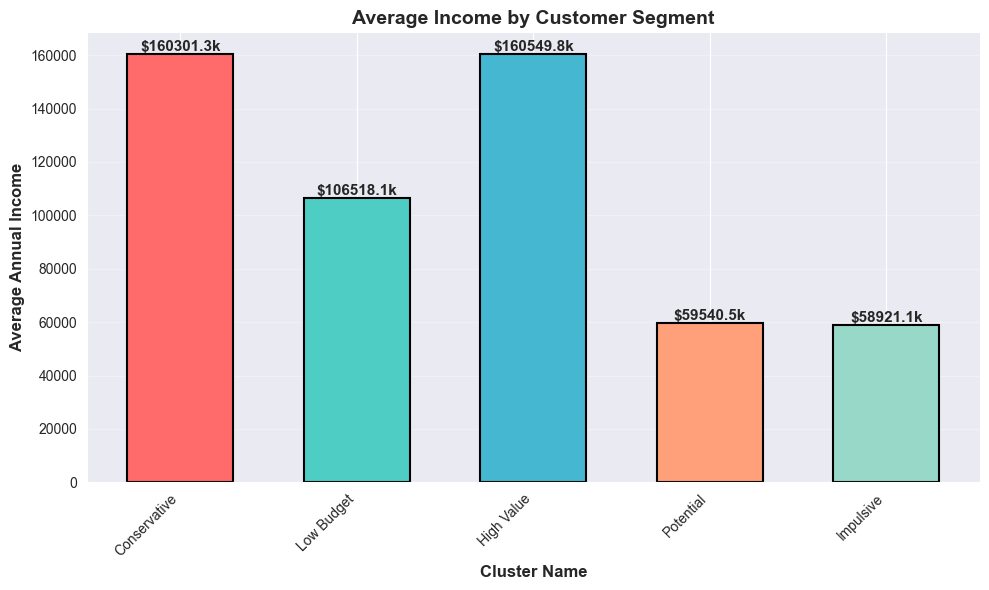

In [116]:
plt.figure(figsize=(10, 6))
avg_income_cluster = df.groupby('Cluster')['Annual Income'].mean()
bars = plt.bar([labels_map[c] for c in avg_income_cluster.index], avg_income_cluster.values,
               color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.1f}k', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Cluster Name', fontsize=12, fontweight='bold')
plt.ylabel('Average Annual Income', fontsize=12, fontweight='bold')
plt.title('Average Income by Customer Segment', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bar Chart: Average Spending Score by Cluster

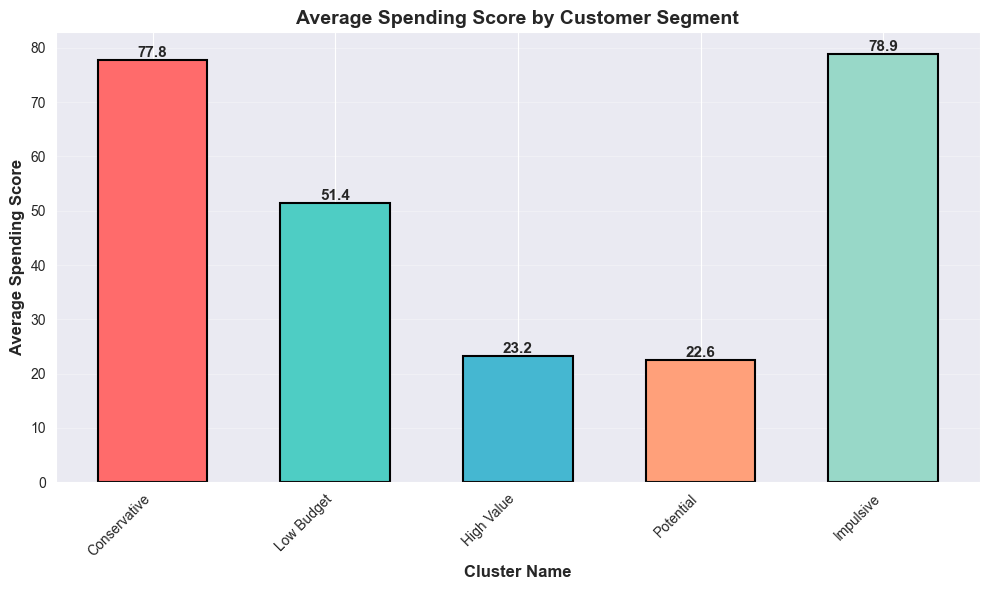

In [117]:
plt.figure(figsize=(10, 6))
avg_spending_cluster = df.groupby('Cluster')['Spending Score'].mean()
bars = plt.bar([labels_map[c] for c in avg_spending_cluster.index], avg_spending_cluster.values,
               color=colors, edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xlabel('Cluster Name', fontsize=12, fontweight='bold')
plt.ylabel('Average Spending Score', fontsize=12, fontweight='bold')
plt.title('Average Spending Score by Customer Segment', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Donut Chart: Gender Distribution by Cluster

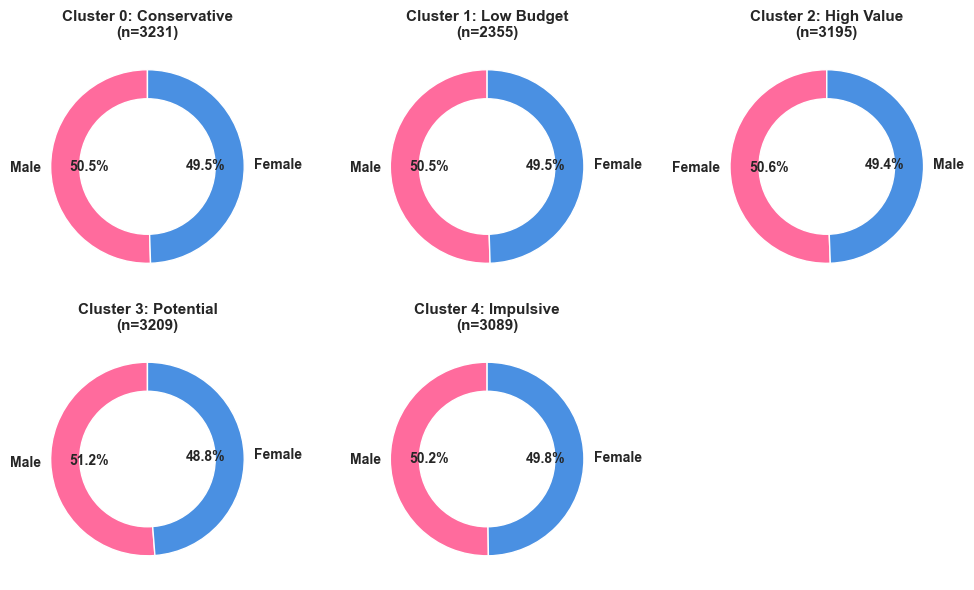

In [122]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for cluster in range(BEST_K):
    cluster_data = df[df['Cluster'] == cluster]
    gender_dist = cluster_data['Gender'].value_counts()
    
    ax = axes[cluster]
    wedges, texts, autotexts = ax.pie(gender_dist, 
                                        labels=gender_dist.index,
                                        autopct='%1.1f%%',
                                        colors=['#FF6B9D', '#4A90E2'],
                                        startangle=90,
                                        textprops={'fontsize': 10, 'fontweight': 'bold'})
    
    # Draw circle for donut
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    
    ax.set_title(f'Cluster {cluster}: {labels_map[cluster]}\n(n={len(cluster_data)})', 
                fontsize=11, fontweight='bold')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


### Final Summary Report

In [119]:
for cluster in range(BEST_K):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCLUSTER {cluster}: {labels_map[cluster].upper()}")
    print("-" * 80)
    print(f"  Number of Customers:      {len(cluster_data)} ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"  Average Age:              {cluster_data['Age'].mean():.1f} years (std: {cluster_data['Age'].std():.1f})")
    print(f"  Average Income:           ${cluster_data['Annual Income'].mean():.1f}k (std: ${cluster_data['Annual Income'].std():.1f}k)")
    print(f"  Average Spending Score:   {cluster_data['Spending Score'].mean():.1f}/100 (std: {cluster_data['Spending Score'].std():.1f})")
    print(f"  Female Percentage:        {cluster_data['Gender_num'].mean()*100:.1f}%")
    print(f"  Male Percentage:          {(1-cluster_data['Gender_num'].mean())*100:.1f}%")



CLUSTER 0: CONSERVATIVE
--------------------------------------------------------------------------------
  Number of Customers:      3231 (21.4%)
  Average Age:              54.2 years (std: 21.4)
  Average Income:           $160301.3k (std: $24026.6k)
  Average Spending Score:   77.8/100 (std: 13.7)
  Female Percentage:        49.5%
  Male Percentage:          50.5%

CLUSTER 1: LOW BUDGET
--------------------------------------------------------------------------------
  Number of Customers:      2355 (15.6%)
  Average Age:              54.3 years (std: 21.2)
  Average Income:           $106518.1k (std: $20767.5k)
  Average Spending Score:   51.4/100 (std: 11.1)
  Female Percentage:        49.5%
  Male Percentage:          50.5%

CLUSTER 2: HIGH VALUE
--------------------------------------------------------------------------------
  Number of Customers:      3195 (21.2%)
  Average Age:              54.3 years (std: 21.2)
  Average Income:           $160549.8k (std: $24332.3k)
  Averag